In [ ]:
## Task 2 - FS only evaluation

# the 3 models (ElasticNet, SVR, BayesianRidge) evaluated on the mRMR feature set

In [1]:
import pandas as pd
import numpy as np
import sys, os
sys.path.append(os.path.abspath('..'))
 
from src.functions import (
    load_data, get_feature_matrix_target_and_features,
    split_stratified_data, build_num_preprocessor,
    evaluate_model_bootstraping, print_evaluation_results,
    build_results_table, get_comparison_boxplot
)
from mrmr import mrmr_regression
from sklearn.pipeline import Pipeline
from sklearn.linear_model import ElasticNet, BayesianRidge
from sklearn.svm import SVR

In [2]:
# Load data
df_development = load_data('../data/development_data.csv')
target_column = "age"
first_column_name = df_development.columns[0]
df_development.set_index(first_column_name, inplace=True)
 
X, y, cpg_features, cat_features = get_feature_matrix_target_and_features(df_development, target_column)
X_train, X_val, y_train, y_val = split_stratified_data(X, y, n_bins=5, test_size=0.2, random_state=42)
 
X_train_num = X_train[cpg_features]
X_val_num   = X_val[cpg_features]
 
# Preprocess & mRMR (same as Task 3)
num_preprocessor = build_num_preprocessor()
X_num_preprocessed     = num_preprocessor.fit_transform(X_train_num)
X_val_num_preprocessed = num_preprocessor.transform(X_val_num)
 
X_num_df     = pd.DataFrame(X_num_preprocessed,     columns=cpg_features, index=X_train_num.index)
X_val_num_df = pd.DataFrame(X_val_num_preprocessed, columns=cpg_features, index=X_val_num.index)
 
K_best = 197
cpg_mrmr_features = mrmr_regression(X=X_num_df, y=y_train, K=K_best)

100%|██████████| 197/197 [00:23<00:00,  8.41it/s]


In [3]:
# FS-only evaluation (default hyperparameters, mRMR features, validation set)

X_train_mrmr = X_num_df[cpg_mrmr_features]
X_val_mrmr   = X_val_num_df[cpg_mrmr_features]

# ElasticNet (
en_pipe = Pipeline([('model', ElasticNet())])
en_pipe.fit(X_train_mrmr, y_train)
y_pred_en = en_pipe.predict(X_val_mrmr)
en_fs_results, en_fs_dict = evaluate_model_bootstraping(y_val, y_pred_en, n_bootstraps=1000, random_state=42)
print_evaluation_results("ElasticNet (FS-only, mRMR K=197)", en_fs_results)
 
# SVR 
svr_pipe = Pipeline([('model', SVR())])
svr_pipe.fit(X_train_mrmr, y_train)
y_pred_svr = svr_pipe.predict(X_val_mrmr)
svr_fs_results, svr_fs_dict = evaluate_model_bootstraping(y_val, y_pred_svr, n_bootstraps=1000, random_state=42)
print_evaluation_results("SVR (FS-only, mRMR K=197)", svr_fs_results)
 
# BayesianRidge
br_pipe = Pipeline([('model', BayesianRidge())])
br_pipe.fit(X_train_mrmr, y_train)
y_pred_br = br_pipe.predict(X_val_mrmr)
br_fs_results, br_fs_dict = evaluate_model_bootstraping(y_val, y_pred_br, n_bootstraps=1000, random_state=42)
print_evaluation_results("BayesianRidge (FS-only, mRMR K=197)", br_fs_results)
 


ElasticNet (FS-only, mRMR K=197) Results:
RMSE: 5.7151 (95% CI: [4.5964, 6.9397])
MAE: 4.1273 (95% CI: [3.3369, 4.8736])
R2: 0.8408 (95% CI: [0.7483, 0.9055])
PEARSON: 0.9193 (95% CI: [0.8708, 0.9522])

SVR (FS-only, mRMR K=197) Results:
RMSE: 8.8802 (95% CI: [7.1973, 10.8026])
MAE: 6.4777 (95% CI: [5.2693, 7.8050])
R2: 0.6253 (95% CI: [0.5467, 0.7089])
PEARSON: 0.8261 (95% CI: [0.7763, 0.8779])

BayesianRidge (FS-only, mRMR K=197) Results:
RMSE: 5.7123 (95% CI: [4.5176, 7.0926])
MAE: 4.0757 (95% CI: [3.2567, 4.8783])
R2: 0.8405 (95% CI: [0.7411, 0.9101])
PEARSON: 0.9249 (95% CI: [0.8793, 0.9562])


,Stage,RMSE (mean),95% CI,MAE,R²,Pearson r
Model,,,,,,
ElasticNet,FS-only,5.7151,"[4.5964, 6.9397]",4.1273,0.8408,0.9193
SVR,FS-only,8.8802,"[7.1973, 10.8026]",6.4777,0.6253,0.8261
BayesianRidge,FS-only,5.7123,"[4.5176, 7.0926]",4.0757,0.8405,0.9249


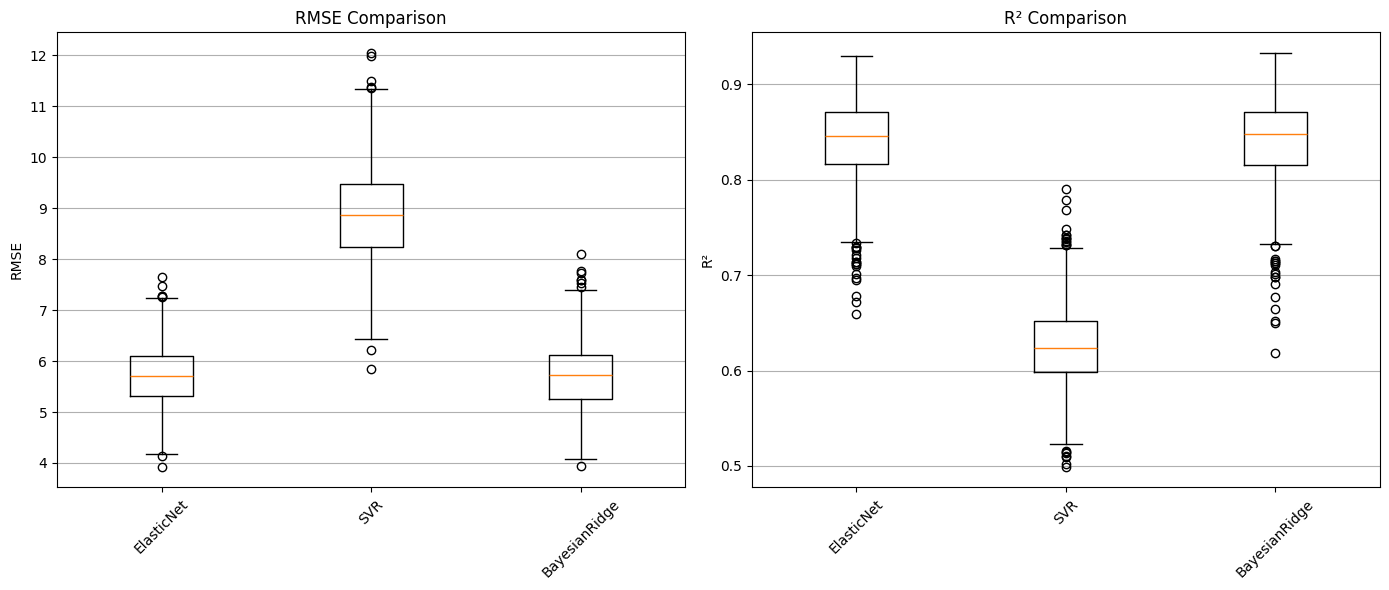

In [4]:
# build FS-only table

fs_only_table = build_results_table({
    'ElasticNet':    en_fs_results,
    'SVR':           svr_fs_results,
    'BayesianRidge': br_fs_results,
}, stage='FS-only')
 
display(fs_only_table)

# boxplots

get_comparison_boxplot({
    'ElasticNet':    en_fs_dict,
    'SVR':           svr_fs_dict,
    'BayesianRidge': br_fs_dict,
}, save_path='../figures/fs_only_models_comparison_boxplot.png')
 